# Benchmark 1D 

In [1]:
import tensorflow.keras.backend as K
from tensorflow.keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from hyperopt.pyll.base import scope
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam,Nadam,Adamax
from ann_functions import getModel, kCrossVal, transfBestparam
from time import perf_counter
import tensorflow as tf
from generalization import Neural_network, MultiFidelity

from cuqi.distribution import Uniform, Gaussian,JointDistribution
from cuqi.sampler import MH
from cuqi.model import Model
from cuqi.geometry import Continuous1D, Discrete
import keras

# Creation of the model

In [2]:
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

HPO = False

#Benchmark1
highfid = lambda x: (6.*x-2.)**2*np.sin(12.*x-4.)
lowfid  = lambda x: 0.5*highfid(x) + 10*(x-0.5) + 5.
Nhf = 5
Nlf = 32
N = Nhf + Nlf
xhf = np.linspace(0,1,Nhf)
xlf = np.linspace(0,1,Nlf)
x_test = np.linspace(0,1,1000)
Yhf = highfid(xhf)
Ylf = lowfid(xlf)

NepoLF = 1000
NepoHF = 500

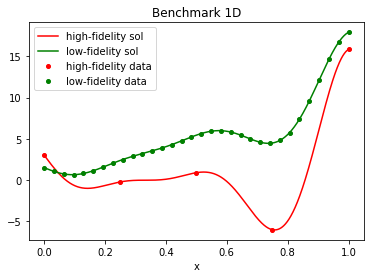

In [3]:
#%% Plot functions
plt.figure()
plt.plot(x_test,highfid(x_test),'r', label = 'high-fidelity sol')
plt.plot(x_test,lowfid(x_test),'g', label = 'low-fidelity sol')
plt.plot(xhf,highfid(xhf),'ro', label = 'high-fidelity data', markersize = 4)
plt.plot(xlf,lowfid(xlf),'go', label = 'low-fidelity data', markersize = 4)
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()

## Low fidelity model

In [4]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelLF=Neural_network('LF',params=bestLF_params,data_train=xlf,output_train=Ylf,N=NepoLF,n=Nlf,train=True,do_HPO=False,verbose=False)
yLF=modelLF.prediction(x_test)


## High fidelity model

In [5]:
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelHF=Neural_network('LF',params=bestHF_params,data_train=xhf,output_train=Yhf,N=NepoHF,n=Nhf,train=True,do_HPO=False,verbose=False)
yHF=modelHF.prediction(x_test)

## 2 Step model

In [6]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010018625799978436, 'lr': 0.07093837044166487, 'nodes': 74.0, 'opt': 'Adamax'}
N=[NepoLF,NepoHF]
n=[Nlf,Nhf]
names=['LF','2step']

params=[bestLF_params,best_params]
final_model=MultiFidelity(names,params=params,data_train_LF=xlf,output_train_LF=Ylf,data_train_HF=xhf,output_train_HF=Yhf,N=N,n=n,do_HPO=False,verbose=False)
y_test=final_model.prediction(x_test)

## Plots

Text(0.5, 1.0, 'High fidelity model - 2-step')

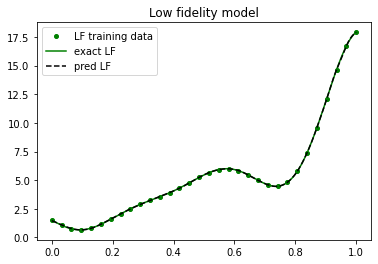

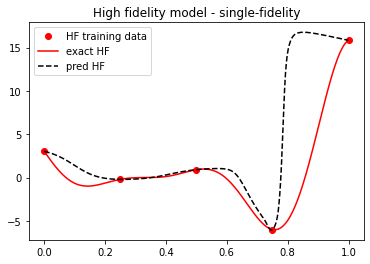

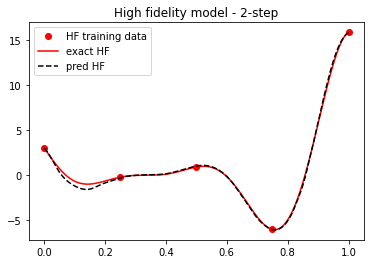

In [7]:
#LF
plt.figure()
plt.plot(xlf,Ylf,'go', label = 'LF training data', markersize = 4)
plt.plot(x_test,lowfid(x_test),'g', label = 'exact LF') 
plt.plot(x_test,yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

#HF single-fidelity
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,yHF,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - single-fidelity')

#2-step MF
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,y_test,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - 2-step')

# MCMC

In [8]:
real_x = np.linspace([0.1,0.3,0.5,0.7,0.9])
observed_output = highfid(real_x)

# Set parameters for the MCMC
n_samples = 400  # Number of samples
initial_x = 0.5 # Initial value for x
proposal_sd = 0.3 # Standard deviation for the proposal distribution

Sample 800 / 800

Average acceptance rate: 0.145 MCMC scale: 0.03540699275868736 

[0.73681878 0.33360384 0.41913597 0.442677   0.57402479]
[0.73751419 0.3227629  0.42188063 0.44489176 0.57129459]
[17.71209478 20.30574947  4.06070772 10.27318432  8.16027288]


array([[<AxesSubplot:title={'center':'v0'}>,
        <AxesSubplot:title={'center':'v1'}>,
        <AxesSubplot:title={'center':'v2'}>],
       [<AxesSubplot:title={'center':'v3'}>,
        <AxesSubplot:title={'center':'v4'}>, <AxesSubplot:>]],
      dtype=object)

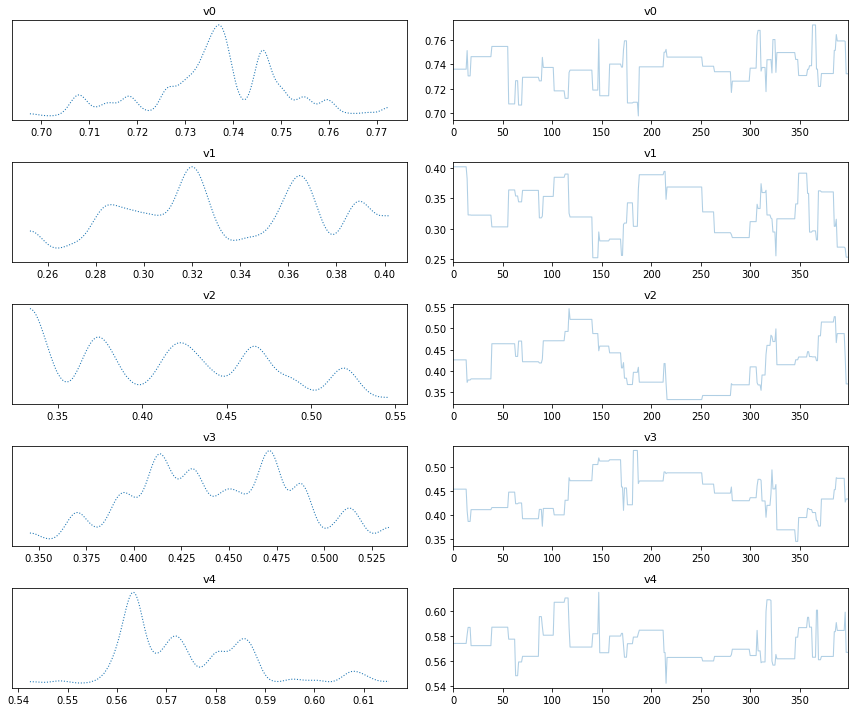

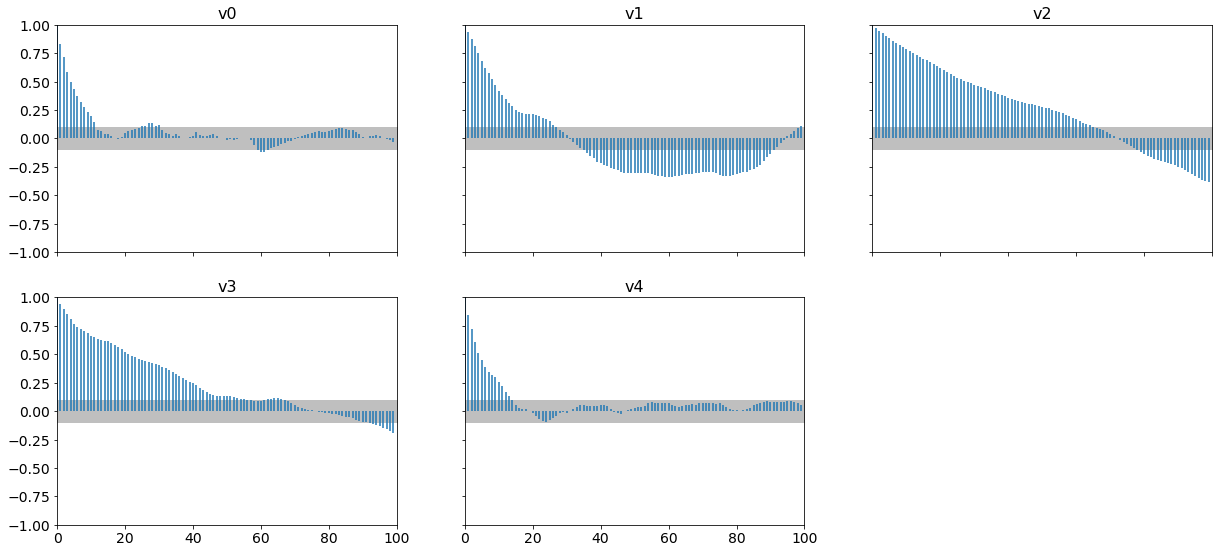

In [9]:
# ATTENZIONE!  in caso LF non si dovrebbe mettere comunque forward=modelHF?


A_LF=Model(forward=modelLF.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
x_LF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
y_LF=Gaussian(mean=A_LF(x_LF),cov=proposal_sd)
y_obs=y_LF(x_LF=real_x).sample()
posterior_LF=JointDistribution(y_LF,x_LF)(y_LF=y_obs)
x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

MHsampler_LF=MH(posterior_LF,x0=x_init)
samplesMH_LF=MHsampler_LF.sample_adapt(n_samples,n_samples)    # N: number of "real" steps Nb: number of burn-in steps # total nb of steps is the sum of the two

samplesMH_LF.plot_trace()
print("mean value")
print(samplesMH_LF.mean())
print("ESS")
print(samplesMH_LF.compute_ess())
samplesMH_LF.plot_autocorrelation()

In [11]:
print(y_obs)
print(modelLF.prediction(real_x))

[ 1.38824237  3.37201907  4.61992713  4.70086233 12.18440542]
[ 0.6589024  2.9802446  5.4663777  4.7054543 11.844086 ]


Sample 600 / 600

Average acceptance rate: 0.14666666666666667 MCMC scale: 0.04051490841657587 

[0.48390249 0.31203909 0.47784541 0.74325578 0.50194125]
[ 8.43605551 10.99103672 23.00196499 15.6296918   7.93966092]


array([[<AxesSubplot:title={'center':'v0'}>,
        <AxesSubplot:title={'center':'v1'}>,
        <AxesSubplot:title={'center':'v2'}>],
       [<AxesSubplot:title={'center':'v3'}>,
        <AxesSubplot:title={'center':'v4'}>, <AxesSubplot:>]],
      dtype=object)

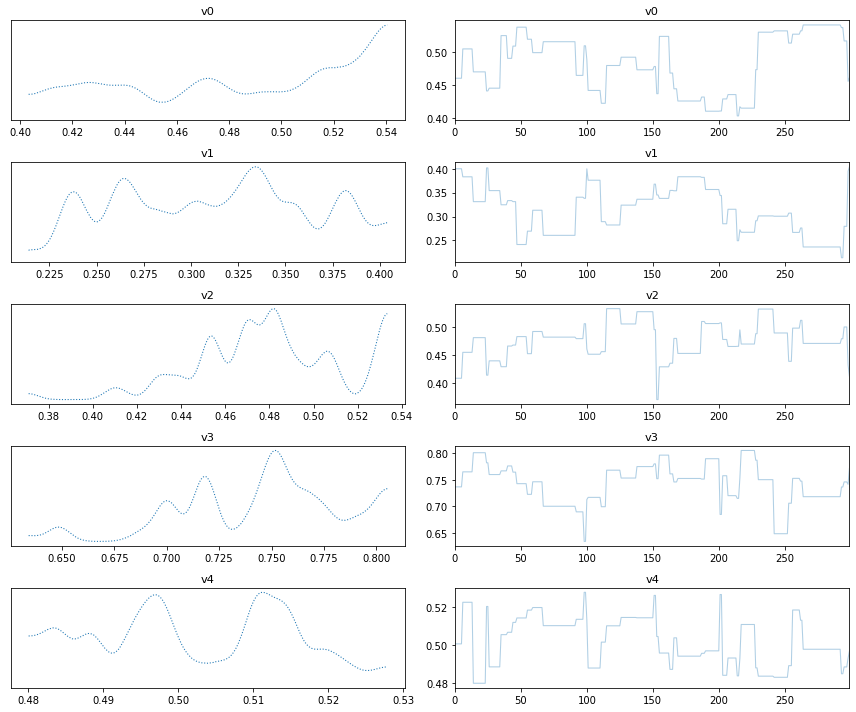

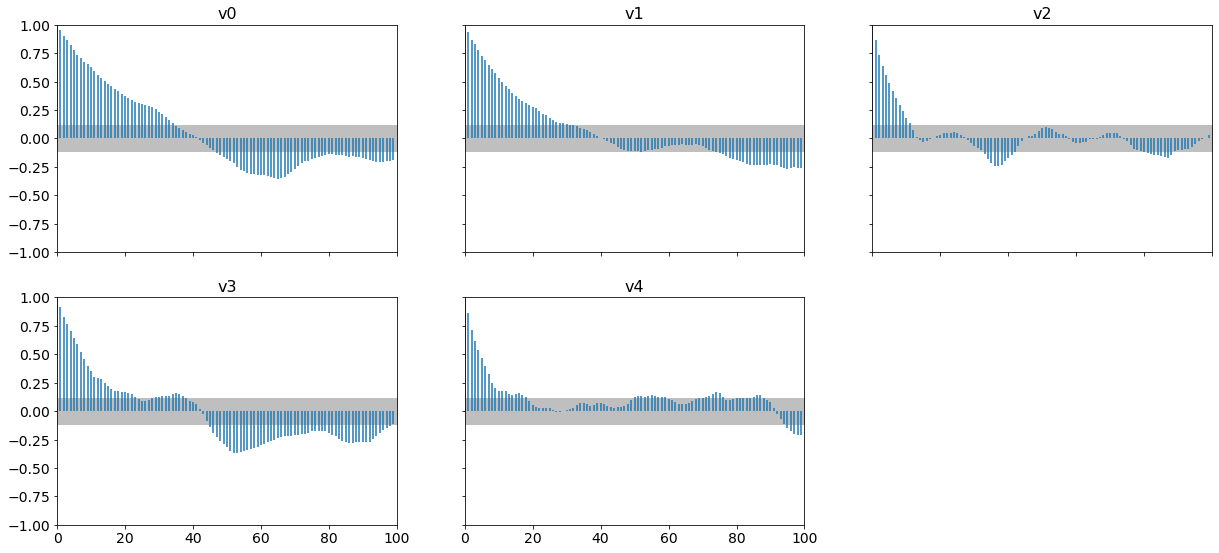

In [ ]:
A_HF=Model(forward=modelHF.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
x_HF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
y_HF=Gaussian(mean=A_HF(x_HF),cov=proposal_sd)
y_obs=y_HF(x_HF=real_x).sample()
posterior_HF=JointDistribution(y_HF,x_HF)(y_HF=y_obs)
x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

MHsampler_HF=MH(posterior_HF,x0=x_init)
samplesMH_HF=MHsampler_HF.sample_adapt(n_samples,n_samples)

samplesMH_HF.plot_trace()
print(samplesMH_HF.mean())
print(samplesMH_HF.compute_ess())
samplesMH_HF.plot_autocorrelation()

Sample 600 / 600

Average acceptance rate: 0.13666666666666666 MCMC scale: 0.04012786795875335 



array([0.23507817, 0.53022968, 0.51405922, 0.21669816, 0.52535724])

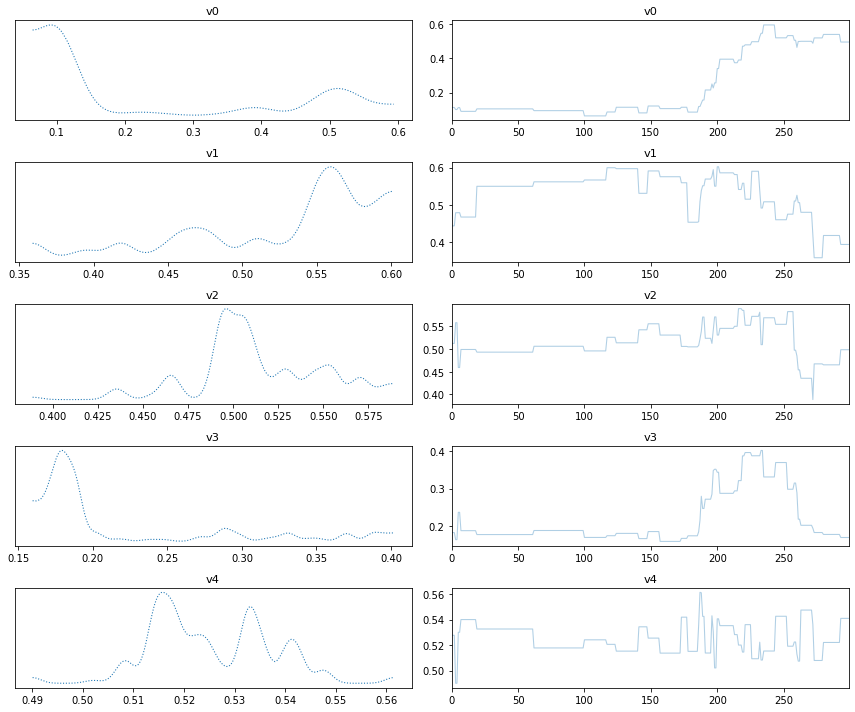

In [ ]:
A_MF=Model(forward=final_model.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
x_MF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
y_MF=Gaussian(mean=A_MF(x_MF),cov=proposal_sd)
y_obs=y_MF(x_MF=real_x).sample()
posterior_MF=JointDistribution(y_MF,x_MF)(y_MF=y_obs)
x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

MHsampler_MF=MH(posterior_MF,x0=x_init)
samplesMH_MF=MHsampler_MF.sample_adapt(n_samples,n_samples)

samplesMH_MF.plot_trace()
samplesMH_MF.mean()
samplesMH_MF.compute_ess()
samplesMH_MF.plot_autocorrelation()

# Discontinuous Benchmark

In [ ]:
lowfid = lambda x: (0.5*(6.*x-2.)**2*np.sin(12.*x-4)+10.*(x-0.5)-5.)*(x<0.5) + (3+0.5*(6.*x-2)**2*np.sin(12.*x-4)+10*(x-0.5)-5.)*(x>0.5)
highfid = lambda x: (2*lowfid(x)- 20*x+20)*(x<0.5) + (4+2*lowfid(x)- 20*x+20)*(x>0.5)
Nhf = 6
Nlf = 32
N = Nhf + Nlf
xhf = np.linspace(0,1,Nhf)
xlf = np.linspace(0,1,Nlf)
x_test = np.linspace(0,1,1000)
Yhf = highfid(xhf)
Ylf = lowfid(xlf)
NepoLF = 5000
NepoHF = 1200

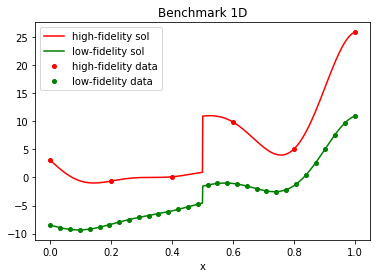

In [ ]:
#%% Plot functions
plt.figure()
plt.plot(x_test,highfid(x_test),'r', label = 'high-fidelity sol')
plt.plot(x_test,lowfid(x_test),'g', label = 'low-fidelity sol')
plt.plot(xhf,highfid(xhf),'ro', label = 'high-fidelity data', markersize = 4)
plt.plot(xlf,lowfid(xlf),'go', label = 'low-fidelity data', markersize = 4)
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()

## Low fidelity model

In [ ]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelLF=Neural_network('LF',params=bestLF_params,data_train=xlf,output_train=Ylf,N=NepoLF,n=Nlf,train=True,do_HPO=False,verbose=False)
yLF=modelLF.prediction(x_test)

## High fidelity model

In [ ]:
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelHF=Neural_network('LF',params=bestHF_params,data_train=xhf,output_train=Yhf,N=NepoHF,n=Nhf,train=True,do_HPO=False,verbose=False)
yHF=modelHF.prediction(x_test)

## 2 Step model

In [ ]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010018625799978436, 'lr': 0.07093837044166487, 'nodes': 74.0, 'opt': 'Adamax'}
N=[NepoLF,NepoHF]
n=[Nlf,Nhf]
names=['LF','2step']

params=[bestLF_params,best_params]
final_model=MultiFidelity(names,params=params,data_train_LF=xlf,output_train_LF=Ylf,data_train_HF=xhf,output_train_HF=Yhf,N=N,n=n,do_HPO=False,verbose=False)
y_test=final_model.prediction(x_test)

## Plots

Text(0.5, 1.0, 'High fidelity model - 2-step')

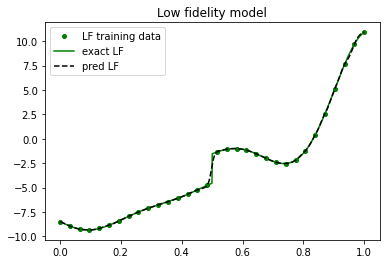

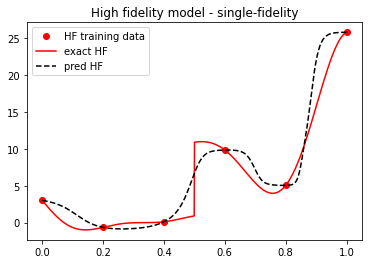

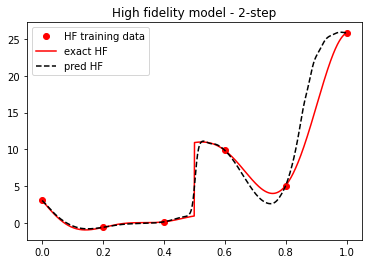

In [ ]:
#LF
plt.figure()
plt.plot(xlf,Ylf,'go', label = 'LF training data', markersize = 4)
plt.plot(x_test,lowfid(x_test),'g', label = 'exact LF') 
plt.plot(x_test,yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

#HF single-fidelity
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,yHF,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - single-fidelity')

#2-step MF
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,y_test,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - 2-step')

# MCMC

In [ ]:
real_x = np.array([0.1,0.3,0.5,0.7,0.9])
observed_output = highfid(real_x)

# Set parameters for the MCMC
n_samples = 300  # Number of samples
initial_x = 0.5 # Initial value for x
proposal_sd = 0.3 # Standard deviation for the proposal distribution

Sample 600 / 600

Average acceptance rate: 0.08 MCMC scale: 0.02923669614702552 



array([0.08784438, 0.7327627 , 0.75940412, 0.71632442, 0.89857366])

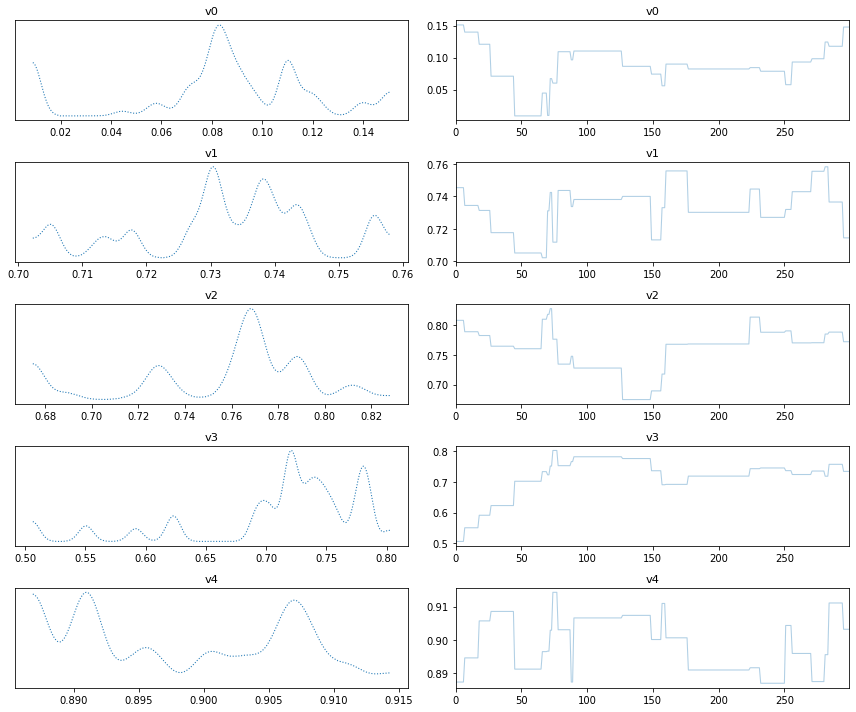

In [ ]:
A_LF=Model(forward=modelLF.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
x_LF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
y_LF=Gaussian(mean=A_LF(x_LF),cov=proposal_sd)
y_obs=y_LF(x_LF=real_x).sample()
posterior_LF=JointDistribution(y_LF,x_LF)(y_LF=y_obs)
x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

MHsampler_LF=MH(posterior_LF,x0=x_init)
samplesMH_LF=MHsampler_LF.sample_adapt(n_samples,n_samples)

samplesMH_LF.plot_trace()
samplesMH_LF.mean()
samplesMH_LF.compute_ess()
samplesMH_LF.plot_autocorrelation()

Sample 600 / 600

Average acceptance rate: 0.016666666666666666 MCMC scale: 0.028623634936841127 



array([0.24195301, 0.26909351, 0.70804902, 0.6875657 , 0.89636388])

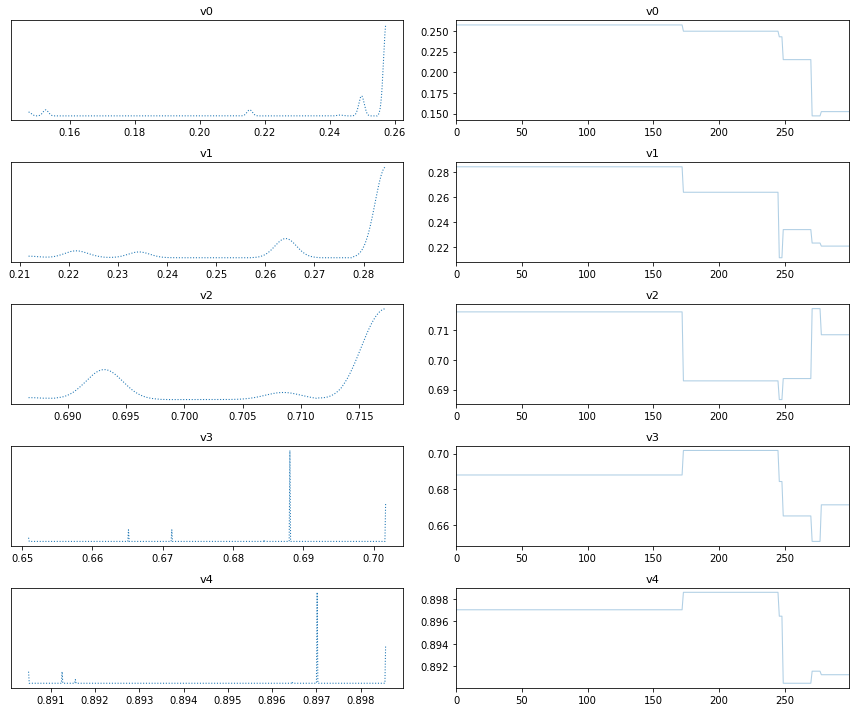

In [ ]:
A_HF=Model(forward=modelHF.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
x_HF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
y_HF=Gaussian(mean=A_HF(x_HF),cov=proposal_sd)
y_obs=y_HF(x_HF=real_x).sample()
posterior_HF=JointDistribution(y_HF,x_HF)(y_HF=y_obs)
x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

MHsampler_HF=MH(posterior_HF,x0=x_init)
samplesMH_HF=MHsampler_HF.sample_adapt(n_samples,n_samples)

samplesMH_HF.plot_trace()
samplesMH_HF.mean()
samplesMH_HF.compute_ess()
samplesMH_HF.plot_autocorrelation()

Sample 600 / 600

Average acceptance rate: 0.02666666666666667 MCMC scale: 0.023386948890714212 



array([0.12233686, 0.20233735, 0.69352968, 0.49773346, 0.90984024])

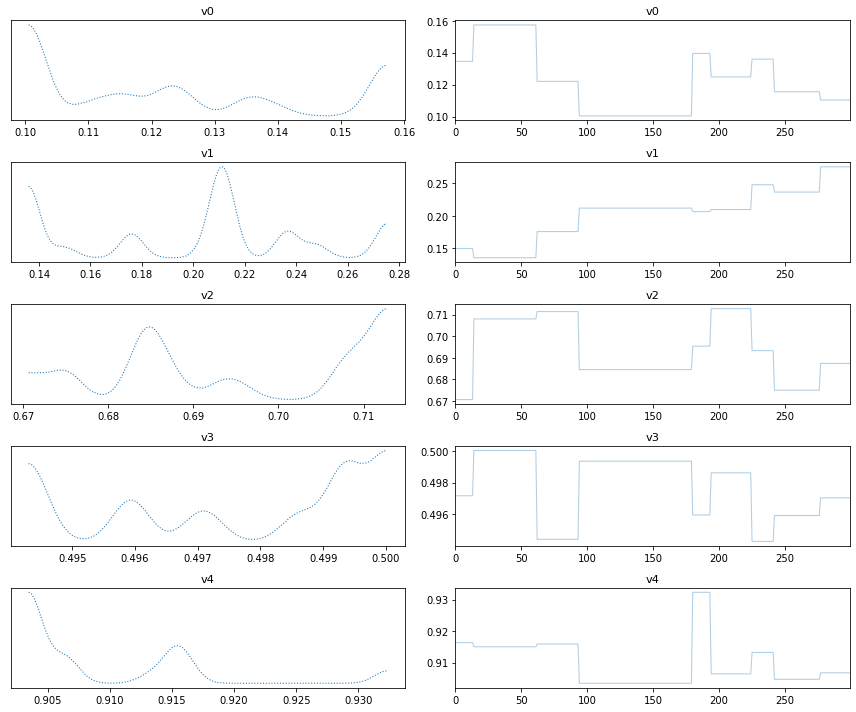

In [ ]:
A_MF=Model(forward=final_model.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
x_MF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
y_MF=Gaussian(mean=A_MF(x_MF),cov=proposal_sd)
y_obs=y_MF(x_MF=real_x).sample()
posterior_MF=JointDistribution(y_MF,x_MF)(y_MF=y_obs)
x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

MHsampler_MF=MH(posterior_MF,x0=x_init)
samplesMH_MF=MHsampler_MF.sample_adapt(n_samples,n_samples)

samplesMH_MF.plot_trace()
samplesMH_MF.mean()
samplesMH_MF.compute_ess()
samplesMH_MF.plot_autocorrelation()

# Nonlinear correlation

OBS: "periodic" case seems not to work

In [ ]:
lowfid = lambda x: np.sin(8*np.pi*x)
highfid = lambda x: (x-np.sqrt(2))*lowfid(x)**2
Nhf = 15
Nlf = 64
N = Nhf + Nlf
xhf = np.linspace(0,1,Nhf)
xlf = np.linspace(0,1,Nlf)
x_test = np.linspace(0,1,1000)
Yhf = highfid(xhf)
Ylf = lowfid(xlf)
NepoLF = 3000
NepoHF = 3000

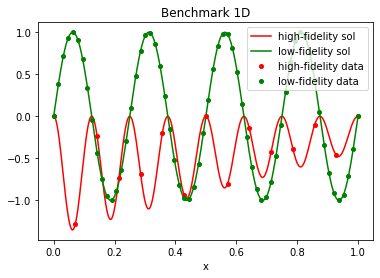

In [ ]:
#%% Plot functions
plt.figure()
plt.plot(x_test,highfid(x_test),'r', label = 'high-fidelity sol')
plt.plot(x_test,lowfid(x_test),'g', label = 'low-fidelity sol')
plt.plot(xhf,highfid(xhf),'ro', label = 'high-fidelity data', markersize = 4)
plt.plot(xlf,lowfid(xlf),'go', label = 'low-fidelity data', markersize = 4)
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()

## Low fidelity model

In [ ]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelLF=Neural_network('LF',params=bestLF_params,data_train=xlf,output_train=Ylf,N=NepoLF,n=Nlf,train=True,do_HPO=False,verbose=False)
yLF=modelLF.prediction(x_test)

## High fidelity model

In [ ]:
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelHF=Neural_network('LF',params=bestHF_params,data_train=xhf,output_train=Yhf,N=NepoHF,n=Nhf,train=True,do_HPO=False,verbose=False)
yHF=modelHF.prediction(x_test)

## 2 Step model

In [ ]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010018625799978436, 'lr': 0.07093837044166487, 'nodes': 74.0, 'opt': 'Adamax'}
N=[NepoLF,NepoHF]
n=[Nlf,Nhf]
names=['LF','2step']

params=[bestLF_params,best_params]
final_model=MultiFidelity(names,params=params,data_train_LF=xlf,output_train_LF=Ylf,data_train_HF=xhf,output_train_HF=Yhf,N=N,n=n,do_HPO=False,verbose=False)
y_test=final_model.prediction(x_test)

## Plots

Text(0.5, 1.0, 'High fidelity model - 2-step')

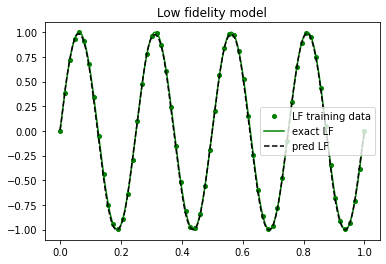

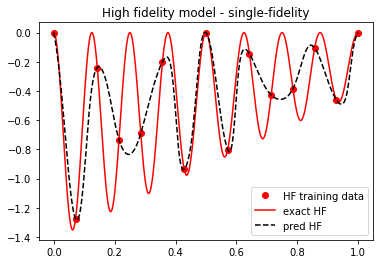

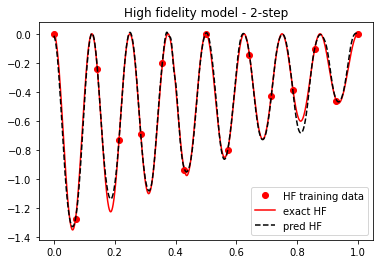

In [ ]:
#LF
plt.figure()
plt.plot(xlf,Ylf,'go', label = 'LF training data', markersize = 4)
plt.plot(x_test,lowfid(x_test),'g', label = 'exact LF') 
plt.plot(x_test,yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

#HF single-fidelity
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,yHF,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - single-fidelity')

#2-step MF
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,y_test,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - 2-step')

# MCMC

In [ ]:
real_x = np.array([0.1,0.3,0.5,0.7,0.9])
observed_output = highfid(real_x)

# Set parameters for the MCMC
n_samples = 300  # Number of samples
initial_x = 0.5 # Initial value for x
proposal_sd = 0.3 # Standard deviation for the proposal distribution

Sample 600 / 600

Average acceptance rate: 0.20333333333333334 MCMC scale: 0.044338058911932175 



array([0.84160488, 0.80779625, 0.53927116, 0.42907475, 0.4357142 ])

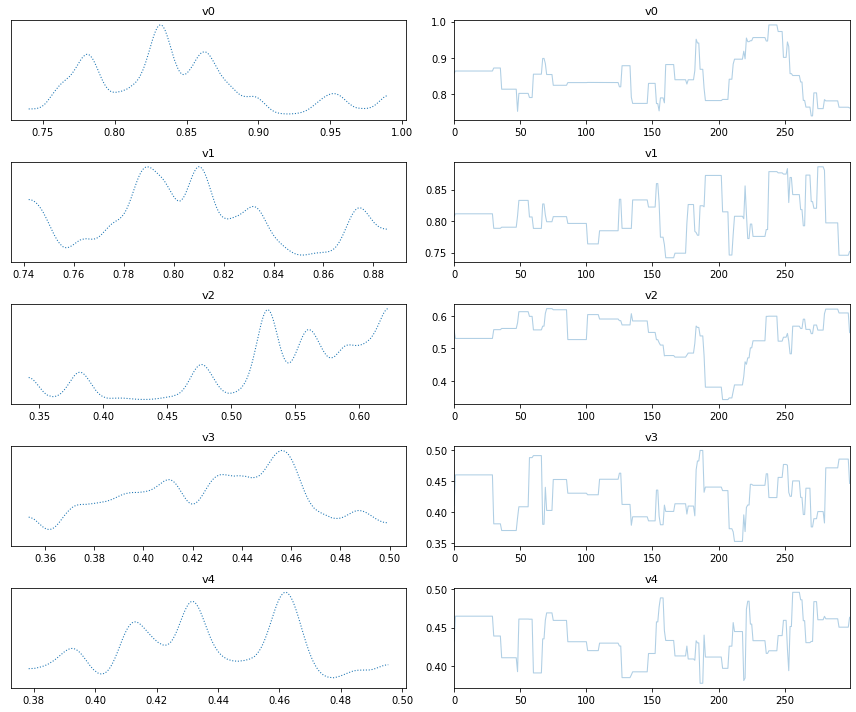

In [ ]:
A_LF=Model(forward=modelLF.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
x_LF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
y_LF=Gaussian(mean=A_LF(x_LF),cov=proposal_sd)
y_obs=y_LF(x_LF=real_x).sample()
posterior_LF=JointDistribution(y_LF,x_LF)(y_LF=y_obs)
x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

MHsampler_LF=MH(posterior_LF,x0=x_init)
samplesMH_LF=MHsampler_LF.sample_adapt(n_samples,n_samples)

samplesMH_LF.plot_trace()
samplesMH_LF.mean()
samplesMH_LF.compute_ess()
samplesMH_LF.plot_autocorrelation()

Sample 600 / 600

Average acceptance rate: 0.25 MCMC scale: 0.21325997508682226 



array([0.54189218, 0.52391214, 0.30068936, 0.57129462, 0.48135374])

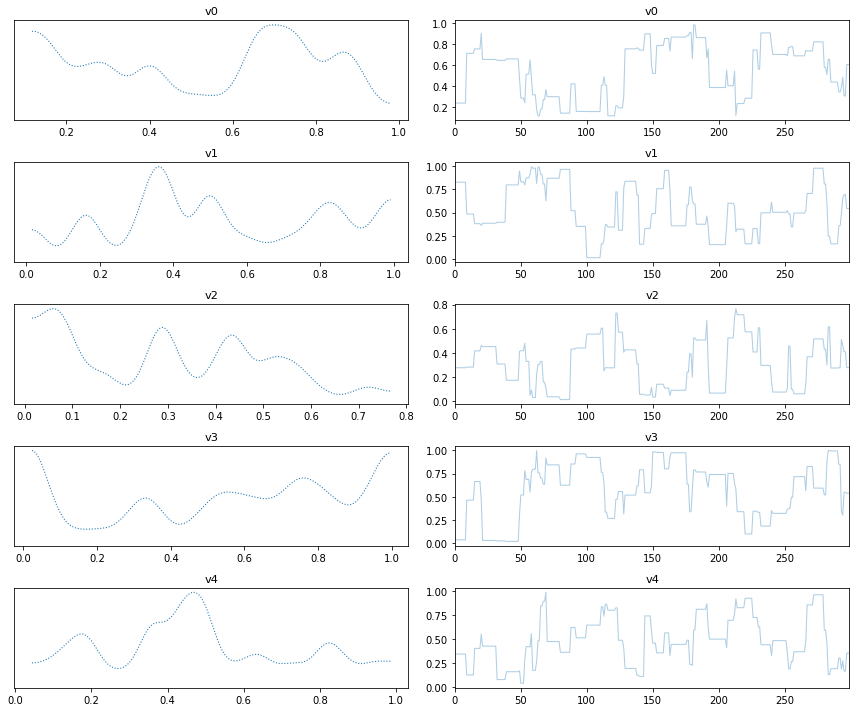

In [ ]:
A_HF=Model(forward=modelHF.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
x_HF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
y_HF=Gaussian(mean=A_HF(x_HF),cov=proposal_sd)
y_obs=y_HF(x_HF=real_x).sample()
posterior_HF=JointDistribution(y_HF,x_HF)(y_HF=y_obs)
x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

MHsampler_HF=MH(posterior_HF,x0=x_init)
samplesMH_HF=MHsampler_HF.sample_adapt(n_samples,n_samples)

samplesMH_HF.plot_trace()
samplesMH_HF.mean()
samplesMH_HF.compute_ess()
samplesMH_HF.plot_autocorrelation()

Sample 600 / 600

Average acceptance rate: 0.22 MCMC scale: 0.16918775217902313 



array([0.38688878, 0.60391827, 0.34670587, 0.55301021, 0.44463978])

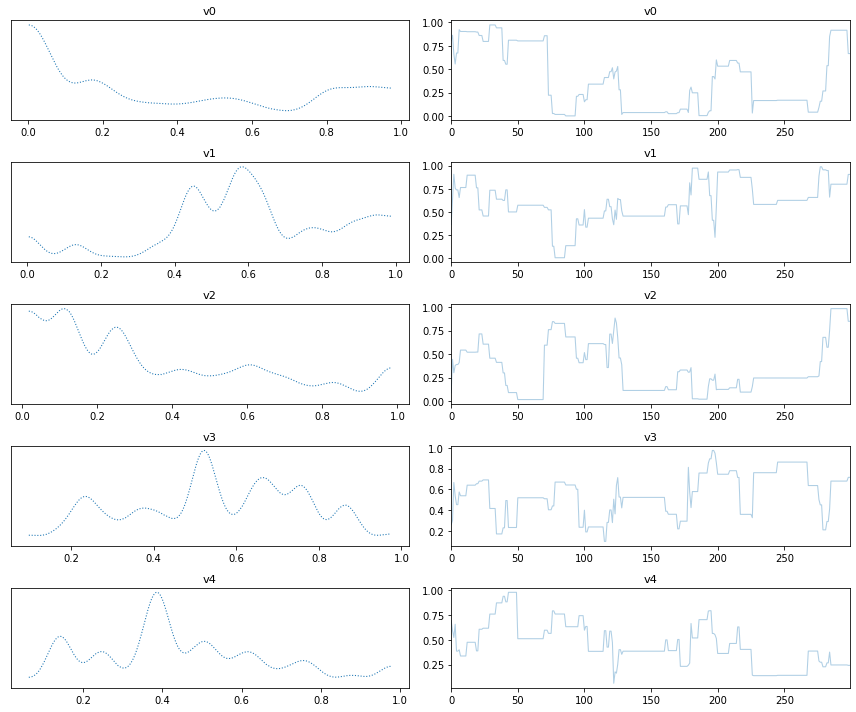

In [ ]:
A_MF=Model(forward=final_model.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
x_MF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
y_MF=Gaussian(mean=A_MF(x_MF),cov=proposal_sd)
y_obs=y_MF(x_MF=real_x).sample()
posterior_MF=JointDistribution(y_MF,x_MF)(y_MF=y_obs)
x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

MHsampler_MF=MH(posterior_MF,x0=x_init)
samplesMH_MF=MHsampler_MF.sample_adapt(n_samples,n_samples)

samplesMH_MF.plot_trace()
samplesMH_MF.mean()
samplesMH_MF.compute_ess()
samplesMH_MF.plot_autocorrelation()